# 2.4 Self-RAG Agent 버전 - 필수 검증 루프 포함

기존 `StateGraph` 기반 Self-RAG 예제를 `create_agent()` 기반 Agent 구조로 변경한 버전입니다.

- 기존 `retrieve` 노드 → `search_pension_law` tool
- 기존 `rewrite` 노드 → `rewrite_query_by_dictionary()` 함수 + system prompt 지시
- 기존 hallucination/helpfulness 검증 → **필수 검증 함수로 분리**
- 최종 답변은 `hallucination` 검증과 `helpfulness` 검증을 모두 통과해야 반환됩니다.

> 핵심: `agent.invoke()`를 직접 호출하면 LangChain Agent만 실행됩니다.  
> 필수 검증까지 포함하려면 이 노트북의 `self_rag_invoke()` 또는 `graph.invoke()`를 사용하세요.


In [1]:
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_upstage import UpstageEmbeddings, ChatUpstage

load_dotenv()

embedding_function = UpstageEmbeddings(model="solar-embedding-1-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name="pension_law_collection",
    persist_directory="./pension_law_collection",
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})
llm = ChatUpstage()

In [2]:
# 사용자의 표현을 국민연금 법령 용어로 바꾸기 위한 간단한 사전입니다.
dictionary = [
    "직장인 -> 사업장가입자",
    "회사원 -> 사업장가입자",
    "근로자 -> 사업장가입자",
    "개인사업자 -> 지역가입자",
    "자영업자 -> 지역가입자",
    "프리랜서 -> 지역가입자",
    "학생 -> 임의가입자",
    "전업주부 -> 임의가입자",
    "주부 -> 임의가입자",
    "외국인 -> 외국인가입자",
    "연금 보험료 -> 연금보험료",
    "국민연금 보험료 -> 연금보험료",
    "보험료 미납 -> 연금보험료 체납",
    "연금 못 냄 -> 연금보험료 체납",
    "가입 해지 -> 가입자 자격 상실",
    "탈퇴 -> 가입자 자격 상실",
    "가입 시작일 -> 자격 취득 시기",
    "가입 끝나는 날 -> 자격 상실 시기",
    "수급자 -> 수급권자",
    "연금 받는 사람 -> 수급권자",
    "노후연금 -> 노령연금",
    "장애 보상 -> 장애연금",
    "사망 후 연금 -> 유족연금",
    "배우자 연금 -> 유족연금",
]


def rewrite_query_by_dictionary(query: str) -> str:
    """간단한 문자열 치환으로 사용자 질문을 법령 용어에 가깝게 보정합니다."""
    rewritten = query

    for item in dictionary:
        source, target = [part.strip() for part in item.split("->")]
        rewritten = rewritten.replace(source, target)

    return rewritten

In [3]:
from typing import Iterable
from langchain_core.documents import Document


def docs_to_text(docs: Iterable[Document]) -> str:
    """검색된 Document 리스트를 Agent tool 반환값으로 쓰기 좋은 문자열로 변환합니다."""
    docs = list(docs or [])

    if not docs:
        return "관련 문서를 찾지 못했습니다."

    chunks = []

    for idx, doc in enumerate(docs, start=1):
        content = getattr(doc, "page_content", "") or ""
        metadata = getattr(doc, "metadata", {}) or {}

        source = (
            metadata.get("source")
            or metadata.get("file_path")
            or metadata.get("title")
            or metadata.get("filename")
            or "출처 정보 없음"
        )
        page = metadata.get("page") or metadata.get("page_number")

        header = f"[검색 결과 {idx}]\n출처: {source}"
        if page is not None:
            header += f"\n페이지: {page}"

        chunks.append(f"{header}\n내용:\n{content}")

    return "\n\n---\n\n".join(chunks)

In [4]:
from langchain_core.tools import tool


@tool
def search_pension_law(query: str) -> str:
    """국민연금 법령/문서에서 질문과 관련된 내용을 검색합니다."""
    rewritten_query = rewrite_query_by_dictionary(query)
    docs = retriever.invoke(rewritten_query)
    return docs_to_text(docs)

In [5]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

hallucination_prompt = PromptTemplate.from_template("""
당신은 국민연금 법령/문서 기반 답변의 근거성을 평가하는 채점자입니다.

아래 검색 문서와 학생 답변을 비교하세요.
답변이 검색 문서에 근거하면 "not hallucinated"를 반환하세요.
답변이 검색 문서에 근거하지 않거나, 문서에 없는 내용을 추측하면 "hallucinated"를 반환하세요.

반드시 아래 형식으로만 답하세요.

Result: not hallucinated 또는 hallucinated
Explanation: 간단한 이유

[검색 문서]
{documents}

[학생 답변]
{answer}
""")

helpfulness_prompt = PromptTemplate.from_template("""
당신은 답변이 사용자의 질문 해결에 도움이 되는지 평가하는 채점자입니다.

아래 질문과 답변을 보고 평가하세요.
답변이 질문에 직접 답하고 유용하면 Score: 1을 반환하세요.
답변이 질문과 무관하거나, 불완전하거나, 질문을 해결하지 못하면 Score: 0을 반환하세요.

반드시 아래 형식으로만 답하세요.

Score: 1 또는 0
Explanation: 간단한 이유

[질문]
{question}

[답변]
{answer}
""")


def parse_hallucination_result(text: str) -> str:
    """LLM 평가 결과에서 hallucination 판정을 안전하게 추출합니다."""
    text = (text or "").lower()

    if "not hallucinated" in text:
        return "not hallucinated"
    if "hallucinated" in text:
        return "hallucinated"

    # 형식이 깨졌을 때는 안전하게 실패 처리합니다.
    return "hallucinated"


def parse_helpfulness_result(text: str) -> str:
    """LLM 평가 결과에서 helpfulness 판정을 안전하게 추출합니다."""
    text = (text or "").lower()

    if "score: 1" in text or "score 1" in text:
        return "helpful"
    if "score: 0" in text or "score 0" in text:
        return "unhelpful"

    # 형식이 깨졌을 때는 안전하게 실패 처리합니다.
    return "unhelpful"


def check_hallucination(question: str, answer: str, documents: str) -> dict:
    """답변이 검색 문서에 근거하는지 필수 검증합니다."""
    chain = hallucination_prompt | llm | StrOutputParser()
    raw = chain.invoke({
        "documents": documents,
        "answer": answer,
    })
    decision = parse_hallucination_result(raw)
    return {
        "decision": decision,
        "raw": raw,
        "passed": decision == "not hallucinated",
    }


def check_helpfulness(question: str, answer: str) -> dict:
    """답변이 사용자 질문에 도움이 되는지 필수 검증합니다."""
    chain = helpfulness_prompt | llm | StrOutputParser()
    raw = chain.invoke({
        "question": question,
        "answer": answer,
    })
    decision = parse_helpfulness_result(raw)
    return {
        "decision": decision,
        "raw": raw,
        "passed": decision == "helpful",
    }


def verify_answer_required(question: str, answer: str, documents: str) -> dict:
    """hallucination 검증과 helpfulness 검증을 반드시 모두 실행합니다."""
    hallucination = check_hallucination(question, answer, documents)
    helpfulness = check_helpfulness(question, answer)

    passed = hallucination["passed"] and helpfulness["passed"]

    return {
        "passed": passed,
        "hallucination": hallucination,
        "helpfulness": helpfulness,
    }


In [6]:
from langchain.agents import create_agent

system_prompt = f"""
당신은 국민연금 법령/문서를 기반으로 답변하는 Self-RAG 스타일 Agent입니다.

역할:
1. 국민연금, 연금보험료, 가입자, 수급권자, 노령연금, 장애연금, 유족연금 관련 질문에는 반드시 search_pension_law tool을 사용하세요.
2. 사용자가 일상 표현을 쓰면 아래 사전을 참고해 법령 용어로 이해하세요.
3. 검색 결과에 근거해서만 답변하세요.
4. 검색 결과에 없는 내용은 추측하지 말고, 문서에서 확인되지 않는다고 말하세요.
5. 답변을 작성하기 전 스스로 점검하세요.
   - 답변이 검색 문서에 근거하는가?
   - 사용자의 질문에 직접 도움이 되는가?
6. 근거가 부족하면 다시 search_pension_law tool을 호출해 다른 표현으로 검색하세요.
7. 최종 답변은 한국어로 간결하게 작성하세요.

주의:
- 이 system prompt의 자기 점검은 1차 점검입니다.
- 실제 최종 반환 전에는 self_rag_invoke()에서 hallucination/helpfulness 검증을 필수로 다시 실행합니다.

용어 사전:
{dictionary}
"""

agent = create_agent(
    model=llm,
    tools=[search_pension_law],
    system_prompt=system_prompt,
)


## Agent 그래프 확인

`create_agent()`도 내부적으로 LangGraph 기반이라 `get_graph()`로 구조를 확인할 수 있습니다.

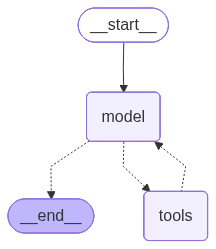

In [7]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG 출력 실패:", e)
    print(agent.get_graph().draw_mermaid())

## 필수 검증 실행 함수

`agent.invoke()`만 직접 호출하면 검증 루프 없이 Agent만 실행됩니다.  
아래 `self_rag_invoke()`는 다음 흐름을 반드시 거칩니다.

```text
질문 → Agent 답변 생성 → hallucination 검증 → helpfulness 검증 → 통과 시 최종 반환
                                      ↓ 실패
                               질문 rewrite 후 재시도
```


In [8]:
def get_final_message_content(result: dict) -> str:
    """create_agent 실행 결과에서 마지막 AI 메시지 내용을 추출합니다."""
    messages = result.get("messages", [])
    if not messages:
        return ""

    last_message = messages[-1]
    return getattr(last_message, "content", str(last_message))


def build_retry_query(original_query: str, attempt: int, verification: dict) -> str:
    """검증 실패 시 Agent에게 다시 시도하도록 질문을 보강합니다."""
    hallucination_raw = verification["hallucination"]["raw"]
    helpfulness_raw = verification["helpfulness"]["raw"]

    rewritten_query = rewrite_query_by_dictionary(original_query)

    return f"""
다음 질문에 다시 답변하세요.
반드시 search_pension_law tool을 다시 사용하고, 검색 결과에 직접 근거한 내용만 답변하세요.

원래 질문:
{original_query}

법령 용어로 보정한 질문:
{rewritten_query}

이전 답변 검증 결과:
[근거성 검증]
{hallucination_raw}

[도움성 검증]
{helpfulness_raw}

재시도 번호: {attempt}
""".strip()


def self_rag_invoke(query: str, max_attempts: int = 3) -> dict:
    """Agent 답변 생성 후 hallucination/helpfulness 검증을 필수로 수행합니다.

    max_attempts 안에 검증을 통과하지 못하면 마지막 답변과 검증 결과를 반환하되,
    passed=False로 표시합니다.
    """
    current_query = query
    attempts = []

    for attempt in range(1, max_attempts + 1):
        # 검증용 문서는 매 시도마다 현재 질문 기준으로 다시 검색합니다.
        rewritten_query = rewrite_query_by_dictionary(current_query)
        docs = retriever.invoke(rewritten_query)
        documents = docs_to_text(docs)

        result = agent.invoke({
            "messages": [
                {"role": "user", "content": current_query}
            ]
        })
        answer = get_final_message_content(result)

        verification = verify_answer_required(
            question=query,
            answer=answer,
            documents=documents,
        )

        attempt_record = {
            "attempt": attempt,
            "query": current_query,
            "rewritten_query": rewritten_query,
            "answer": answer,
            "documents": documents,
            "verification": verification,
            "messages": result.get("messages", []),
        }
        attempts.append(attempt_record)

        if verification["passed"]:
            return {
                "query": query,
                "answer": answer,
                "passed": True,
                "attempts": attempts,
                "verification": verification,
                "messages": result.get("messages", []),
            }

        current_query = build_retry_query(query, attempt + 1, verification)

    # 모든 재시도 실패 시 마지막 결과 반환
    last = attempts[-1]
    return {
        "query": query,
        "answer": last["answer"],
        "passed": False,
        "attempts": attempts,
        "verification": last["verification"],
        "messages": last["messages"],
        "warning": "최대 재시도 횟수 안에 hallucination/helpfulness 검증을 모두 통과하지 못했습니다.",
    }


In [9]:
## 실행 예시

In [10]:
query = "일반적으로 직장인은 언제 연금을 수령할 수 있나요?"

result = self_rag_invoke(query, max_attempts=3)

print("검증 통과 여부:", result["passed"])
print("시도 횟수:", len(result["attempts"]))
print("\n최종 답변:\n", result["answer"])
print("\n최종 검증 결과:\n", result["verification"])


검증 통과 여부: False
시도 횟수: 3

최종 답변:
 검색 결과에 따르면, 사업장가입자가 연금을 수령할 수 있는 시기에 대한 구체적인 정보는 없습니다. 더 자세한 정보를 얻기 위해서는 국민연금 법령/문서에서 더 자세한 검색을 권장합니다.

최종 검증 결과:
 {'passed': False, 'hallucination': {'decision': 'not hallucinated', 'raw': 'Result: not hallucinated\nExplanation: 학생 답변은 검색 결과에 따라 사업장가입자가 연금을 수령할 수 있는 시기에 대한 구체적인 정보가 없다고 정확하게 표현하고 있습니다. 또한, 더 자세한 정보를 얻기 위해서는 국민연금 법령/문서에서 더 자세한 검색이 필요하다는 합리적인 제안을 하고 있습니다. 따라서 학생 답변은 검색 문서에 근거하고 있으며, 문서에 없는 내용을 추측하지 않았습니다.', 'passed': True}, 'helpfulness': {'decision': 'unhelpful', 'raw': 'Score: 0\nExplanation: 답변은 사용자의 질문에 직접적으로 답하지 않고, 일반적인 검색 결과를 언급하며 더 자세한 정보를 얻기 위해 다른 곳을 찾아보라고만 안내하고 있습니다. 질문은 일반적으로 직장인이 연금을 수령할 수 있는 시기에 대한 구체적인 정보를 요구했지만, 답변은 이를 충족시키지 못했습니다.', 'passed': False}}


## 기존 `graph.invoke({"query": ...})` 방식과 비슷하게 쓰고 싶은 경우

아래 래퍼를 사용하면 기존 예제와 유사하게 `graph.invoke({"query": 질문})` 형태로 호출할 수 있습니다.  
이 래퍼도 내부적으로 `self_rag_invoke()`를 사용하므로, **hallucination/helpfulness 검증은 필수로 실행됩니다.**


In [11]:
class AgentGraphWrapper:
    """기존 StateGraph 예제의 graph.invoke({'query': ...}) 사용감을 맞추기 위한 래퍼입니다.

    이 래퍼는 agent.invoke()를 바로 호출하지 않고 self_rag_invoke()를 호출합니다.
    따라서 hallucination/helpfulness 검증이 필수로 실행됩니다.
    """

    def __init__(self, agent, max_attempts: int = 3):
        self.agent = agent
        self.max_attempts = max_attempts

    def invoke(self, state: dict) -> dict:
        query = state.get("query") or state.get("question") or ""
        result = self_rag_invoke(query, max_attempts=self.max_attempts)

        return {
            "query": query,
            "answer": result["answer"],
            "passed": result["passed"],
            "attempts": result["attempts"],
            "verification": result["verification"],
            "messages": result["messages"],
        }

    def get_graph(self):
        return self.agent.get_graph()


graph = AgentGraphWrapper(agent, max_attempts=3)


In [12]:
graph_result = graph.invoke({"query": "일반적으로 직장인은 언제 연금을 수령할 수 있나요?"})

print("검증 통과 여부:", graph_result["passed"])
print("최종 답변:\n", graph_result["answer"])
print("검증 결과:\n", graph_result["verification"])


검증 통과 여부: False
최종 답변:
 죄송하지만, 사업장가입자가 연금을 수령할 수 있는 시기에 대한 구체적인 정보를 검색 결과에서 찾을 수 없습니다. 더 자세한 정보를 얻기 위해서는 국민연금 법령/문서를 더 자세히 검색하거나, 국민연금공단에 문의하시는 것이 좋을 것 같습니다.
검증 결과:
 {'passed': False, 'hallucination': {'decision': 'hallucinated', 'raw': 'Result: hallucinated\nExplanation: 학생의 답변은 검색 문서에 없는 정보를 제공하고 있습니다. 검색 문서에는 관련 문서를 찾지 못했다고만 나와 있고, 사업장가입자가 연금을 수령할 수 있는 시기에 대한 정보는 없습니다. 그러나 학생의 답변에는 연금 수령 시기에 대한 정보가 언급되어 있어, 이는 검색 문서에 근거하지 않은 내용입니다.', 'passed': False}, 'helpfulness': {'decision': 'unhelpful', 'raw': 'Score: 0\nExplanation: 답변은 사용자의 질문에 직접 대답하지 않고, 정보를 찾을 수 없었다는 점과 다른 방법을 제안하는 내용에 그치기 때문입니다. 질문에 대한 명확한 답변을 제공하지 않아 사용자의 질문 해결을 돕지 못합니다.', 'passed': False}}
